Group Member: Yashvitha, Yiwen

In [ ]:
# data


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/5e/92/044f1de43901310202f4c79acf4f141be53b2ca8d8380e2fcefb3d523a75/matplotlib-3.11.0-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.5 MB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/pa

Matplotlib is building the font cache; this may take a moment.
[*********************100%***********************]  10 of 10 completed

First 5 rows of adjusted close prices:
Ticker      ABNB       AMZN        COST         DIS         FDX        MSFT  \
Date                                                                          
2020-01-02   NaN  94.900497  265.748383  143.689255  110.980537  151.829529   
2020-01-03   NaN  93.748497  265.967133  142.041016  109.606689  149.938980   
2020-01-06   NaN  95.143997  266.040100  141.216873  109.692551  150.326553   
2020-01-07   NaN  95.343002  265.620667  141.265350  110.765846  148.955917   
2020-01-08   NaN  94.598503  268.665741  140.974487  112.433067  151.328568   

Ticker          NVDA       TSLA           V        XOM  
Date                                                    
2020-01-02  5.970754  28.684000  182.431061  52.947033  
2020-01-03  5.875186  29.534000  180.980164  52.521366  
2020-01-06  5.899825  30.102667  180.588821  52.924637  
2020-01-07  5.971252  31.270666  180.111511  52.491501  
2020-01-08  5.982451  32.809334  183.194687  51.699902  

Last 5 

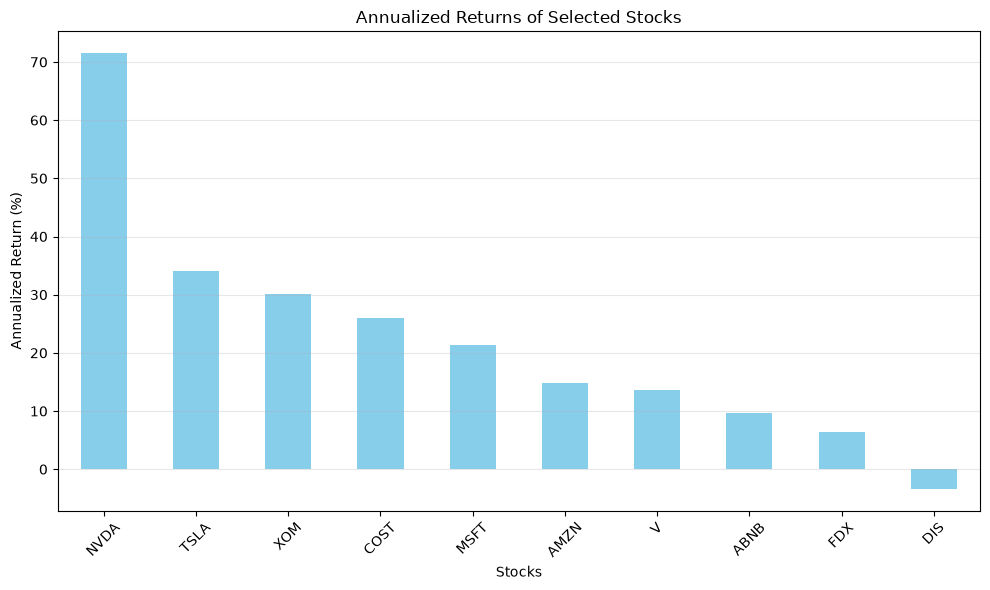

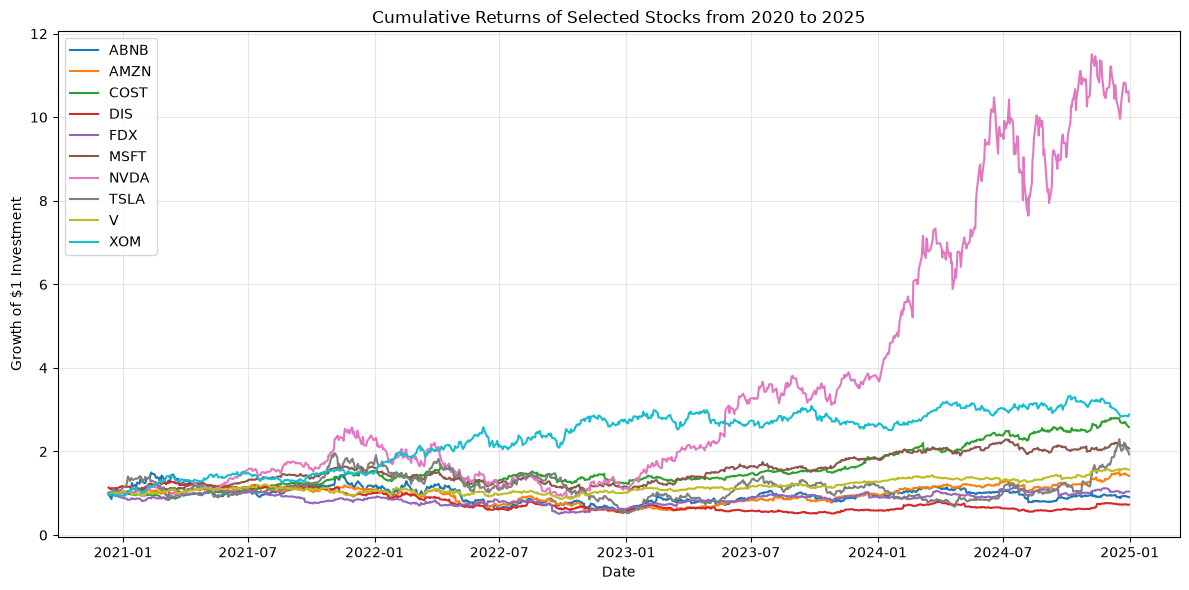

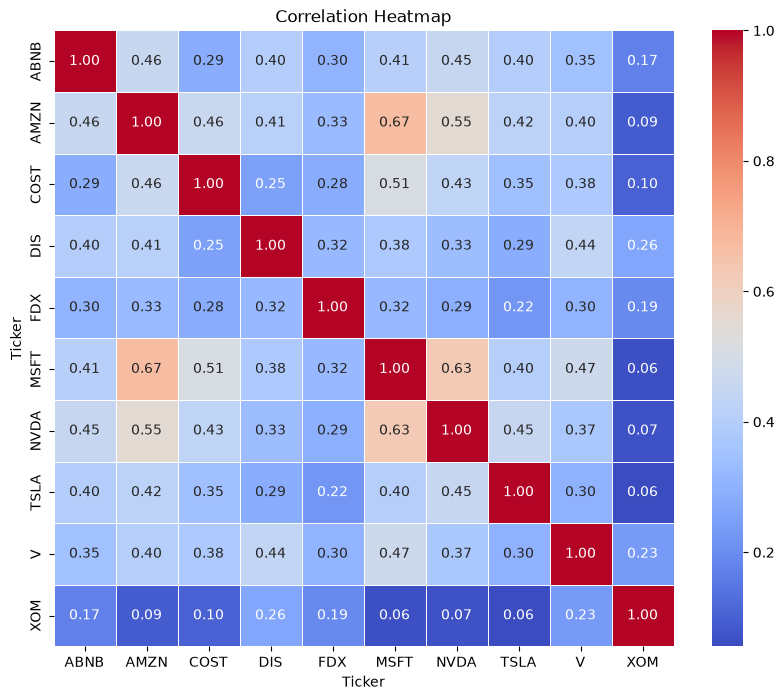


Highest Annualized Return:
Annualized Return        71.52
Annualized Volatility    52.52
Name: NVDA, dtype: float64

Lowest Annualized Return:
Annualized Return        -3.41
Annualized Volatility    29.74
Name: DIS, dtype: float64

Most Volatile Stock:
Annualized Return        34.15
Annualized Volatility    59.99
Name: TSLA, dtype: float64

Least Volatile Stock:
Annualized Return        26.06
Annualized Volatility    22.61
Name: COST, dtype: float64


In [1]:
%pip install yfinance
%pip install matplotlib seaborn
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


TRADING_DAYS = 252

#5 years of data
start_date = "2020-01-01"
end_date = "2025-01-01"
TRADING_DAYS = 252

tickers = [
    "NVDA",   # AI
    "MSFT",   # software
    "TSLA",   # transportation
    "AMZN",   # E-Commerce
    "V",      # payments
    "ABNB",   # travel
    "DIS",    # entertainment
    "XOM",    # energy
    "COST",   # manufacturing
    "FDX"     # logistics
]

adjusted_close_prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]

print("First 5 rows of adjusted close prices:")
print(adjusted_close_prices.head())

print("\nLast 5 rows of adjusted close prices:")
print(adjusted_close_prices.tail())

print("\nMissing values in adjusted close prices:")
print(adjusted_close_prices.isnull().sum())
#remove missing values
adjusted_close_prices = adjusted_close_prices.dropna()
#calculate daily returns
returns = adjusted_close_prices.pct_change().dropna()

print("\nDaily returns:")
print(returns.head())
#calculate average yearly return and volatility
annualized_returns = returns.mean() * TRADING_DAYS
annualized_volatility = returns.std() * np.sqrt(TRADING_DAYS)

summary_stats = pd.DataFrame({
    "Annualized Return": annualized_returns * 100,
    "Annualized Volatility": annualized_volatility * 100
})
summary_stats = summary_stats.round(2)

summary_stats = summary_stats.sort_values(by="Annualized Return", ascending=False)
print("\nSummary statistics (sorted by Annualized Return):")
print(summary_stats)
#plot annualized returns
plt.figure(figsize=(10, 6))
summary_stats["Annualized Return"].plot(kind="bar", color="skyblue")
plt.title("Annualized Returns of Selected Stocks")
plt.xlabel("Stocks")
plt.ylabel("Annualized Return (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#plot cumulative returns
cumulative_returns = (1 + returns).cumprod()
plt.figure(figsize=(12, 6))

for stock in cumulative_returns.columns:
    plt.plot(cumulative_returns.index, cumulative_returns[stock], label=stock)
plt.title("Cumulative Returns of Selected Stocks from 2020 to 2025")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#plot correlation heatmap
correlation_matrix = returns.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(returns.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

print("\nHighest Annualized Return:")
print(summary_stats.loc[summary_stats["Annualized Return"].idxmax()])
print("\nLowest Annualized Return:")
print(summary_stats.loc[summary_stats["Annualized Return"].idxmin()])
print("\nMost Volatile Stock:")
print(summary_stats.loc[summary_stats["Annualized Volatility"].idxmax()])
print("\nLeast Volatile Stock:")
print(summary_stats.loc[summary_stats["Annualized Volatility"].idxmin()])

# Computation part
### Assumptions

- Annualization factor = 252 trading days
# start_date = "2020-01-01"
# end_date = "2025-01-01"
# TRADING_DAYS = 252

- Risk-free rate = 3%
- Long-only portfolio
- Portfolio weights sum to 1
- Sample period: Jan 1, 2020 – Jan 1, 2025

In [2]:
# daily returns
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["NVDA","MSFT","TSLA","AMZN","V","ABNB","DIS","XOM","COST","FDX"]

prices = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]

returns = prices.pct_change().dropna()
returns.head()

[*********************100%***********************]  10 of 10 completed


Ticker,ABNB,AMZN,COST,DIS,FDX,MSFT,NVDA,TSLA,V,XOM
Date,,,,,,,,,,
2020-12-11,-0.037731,0.004814,0.006196,0.135950,-0.002687,0.013015,0.003161,-0.027238,-0.006599,-0.004772
2020-12-14,-0.066427,0.013012,-0.001919,-0.036535,-0.013577,0.004408,0.022708,0.048919,0.004897,-0.036073
2020-12-15,-0.040000,0.002582,-0.006678,0.027407,0.000700,-0.000327,0.003889,-0.010284,0.005356,0.019422
2020-12-16,0.105689,0.023961,-0.006561,-0.004714,0.010744,0.024051,-0.008832,-0.016550,-0.000432,0.015335
2020-12-17,0.065657,-0.001506,0.002301,0.002484,0.011945,0.000638,0.007457,0.053198,0.013972,-0.005035


In [3]:
# annualized income, annualized volatility
annual_returns = returns.mean() * 252
annual_volatility = returns.std() * np.sqrt(252)
cov_matrix = returns.cov() * 252

summary = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})

summary

,Annual Return,Annual Volatility
Ticker,,
ABNB,0.095874,0.489738
AMZN,0.147505,0.351342
COST,0.260604,0.226079
DIS,-0.034075,0.297428
FDX,0.063448,0.323527
MSFT,0.213857,0.259790
NVDA,0.715190,0.525185
TSLA,0.341529,0.599912
V,0.136738,0.226472


In [4]:
# find biggest sharpe ratio
rf = 0.03  # risk-free rate = 3% # Assumption: Fixed annual risk - free rate

num_portfolios = 10000

portfolio_returns = []
portfolio_volatilities = []
sharpe_ratios = []
weights_list = []

for i in range(num_portfolios):
    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)          # All weights are non-negative and sum to one (long-only portfolio)

    port_return = np.dot(weights, annual_returns)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = (port_return - rf) / port_volatility

    portfolio_returns.append(port_return)
    portfolio_volatilities.append(port_volatility)
    sharpe_ratios.append(sharpe)
    weights_list.append(weights)

In [5]:
# find best combination
max_index = np.argmax(sharpe_ratios)

best_return = portfolio_returns[max_index]
best_volatility = portfolio_volatilities[max_index]
best_sharpe = sharpe_ratios[max_index]
best_weights = weights_list[max_index]

print("Best Portfolio Return:", best_return)
print("Best Portfolio Volatility:", best_volatility)
print("Best Sharpe Ratio:", best_sharpe)

optimal_weights = pd.DataFrame({
    "Ticker": tickers,
    "Weight": best_weights
})

optimal_weights = optimal_weights.sort_values (
    by="Weight",
    ascending=False
)

Best Portfolio Return: 0.2919617144874366
Best Portfolio Volatility: 0.1960457778306314
Best Sharpe Ratio: 1.3362272699070903


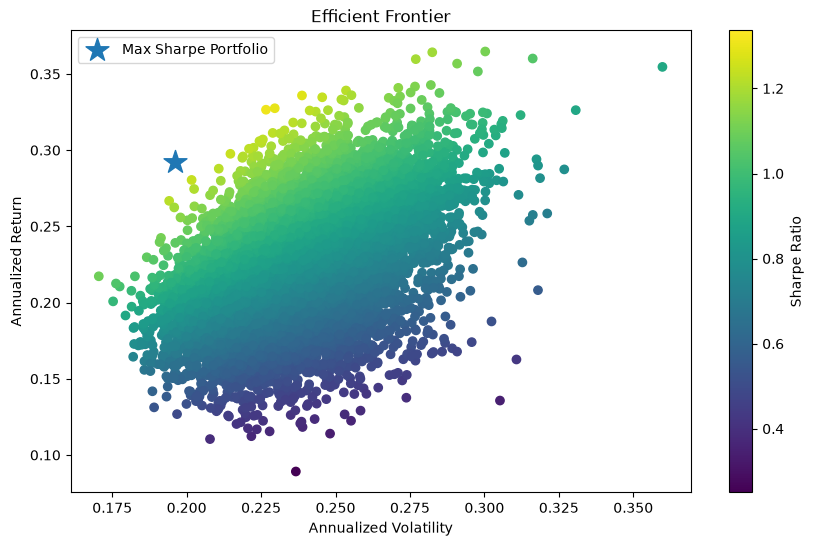

In [6]:
# efficent frontier
plt.figure(figsize=(10,6))

plt.scatter(portfolio_volatilities, portfolio_returns, c=sharpe_ratios)
plt.colorbar(label="Sharpe Ratio")

plt.scatter(best_volatility, best_return, marker="*", s=300, label="Max Sharpe Portfolio")

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Efficient Frontier")
plt.legend()
plt.show()

We generated 10,000 random portfolios using Monte Carlo simulation.

Each portfolio's annualized return, volatility, and Sharpe ratio were calculated.

The portfolio with the highest Sharpe ratio was selected as the optimal portfolio because it provides the best return per unit of risk.